# Import Required Libraries

In [1]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization (optional)
import matplotlib.pyplot as plt

# Model Building
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Algorithms
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Evaluation
from sklearn.metrics import mean_absolute_error, r2_score

# Load Dataset

In [2]:
df = pd.read_csv("Medical_Cost_Intelligence_system/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Define Input (X) and Target (y)

In [3]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [4]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [5]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

### Understand this clearly:

- ##### X = Features

- ##### y = What we predict

# Train-Test Split (75:25)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

In [7]:
X_train.shape, X_test.shape

((1003, 6), (335, 6))

### You should see roughly:

- ##### 75% train

- ##### 25% test

# Identify Column Types

In [8]:
num_cols = ["age", "bmi", "children"]
cat_cols = ["sex", "smoker", "region"]

# Create Preprocessing Pipeline

### Numeric Scaling

In [9]:
num_transformer = StandardScaler()

### Categorical Encoding

In [10]:
cat_transformer = OneHotEncoder(drop="first")

### Combine Both

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols)
    ]
)

# Train First Model (Linear Regression)

In [12]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', LinearRegression())])

## Make Predictions

In [14]:
lr_pred = lr_pipeline.predict(X_test)

## Evaluate Model

In [17]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("MAE:", lr_mae)
print("R2 Score:", lr_r2)

MAE: 4243.654116653143
R2 Score: 0.7672642952734356


# Train KNN Regressor

In [18]:
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsRegressor())
])

# Train KNN Model

In [19]:
knn_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', KNeighborsRegressor())])

## Make Predictions

In [34]:
knn_pred = knn_pipeline.predict(X_test)

## Evaluate KNN

In [35]:
knn_mae = mean_absolute_error(y_test, knn_pred)
knn_r2 = r2_score(y_test, knn_pred)

print("KNN MAE:", knn_mae)
print("KNN R2 Score:", knn_r2)

KNN MAE: 3963.3802143611947
KNN R2 Score: 0.6941304616214053


# SVM Pipeline

In [37]:
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVR())
])

# Train SVM Model

In [38]:
svm_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', SVR())])

## Make Predictions

In [41]:
svm_pred = svm_pipeline.predict(X_test)

## Evaluate SVM

In [43]:
svm_mae = mean_absolute_error(y_test, svm_pred)
svm_r2 = r2_score(y_test, svm_pred)

print("SVM MAE:", svm_mae)
print("SVM R2 Score:", svm_r2)

SVM MAE: 8479.656607663488
SVM R2 Score: -0.09477799126692887


# Create Decision Tree Pipeline

In [44]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

# Train Decision Tree

In [46]:
dt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', DecisionTreeRegressor(random_state=42))])

## Make Predictions

In [47]:
dt_pred = dt_pipeline.predict(X_test)

## Evaluate Decision Tree

In [48]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree MAE:", dt_mae)
print("Decision Tree R2 Score:", dt_r2)

Decision Tree MAE: 2692.336584698507
Decision Tree R2 Score: 0.757579262895574


# Create Random Forest Pipeline

In [49]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

# Train Random Forest

In [50]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', RandomForestRegressor(random_state=42))])

## Make Predictions

In [51]:
rf_pred = rf_pipeline.predict(X_test)

## Evaluate Random Forest

In [52]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest R2 Score:", rf_r2)

Random Forest MAE: 2637.351257640174
Random Forest R2 Score: 0.8479032824381821


# Create Model Comparison Table

In [53]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "KNN",
        "SVM",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        knn_mae,
        svm_mae,
        dt_mae,
        rf_mae
    ],
    "R2 Score": [
        lr_r2,
        knn_r2,
        svm_r2,
        dt_r2,
        rf_r2
    ]
})

results

,Model,MAE,R2 Score
0,Linear Regression,4243.654117,0.767264
1,KNN,3963.380214,0.694130
2,SVM,8479.656608,-0.094778
3,Decision Tree,2692.336585,0.757579
4,Random Forest,2637.351258,0.847903


# Sort by Best Model (Lowest MAE)

In [54]:
results_sorted = results.sort_values(by="MAE")
results_sorted

,Model,MAE,R2 Score
4,Random Forest,2637.351258,0.847903
3,Decision Tree,2692.336585,0.757579
1,KNN,3963.380214,0.694130
0,Linear Regression,4243.654117,0.767264
2,SVM,8479.656608,-0.094778


# Plot Model Comparison

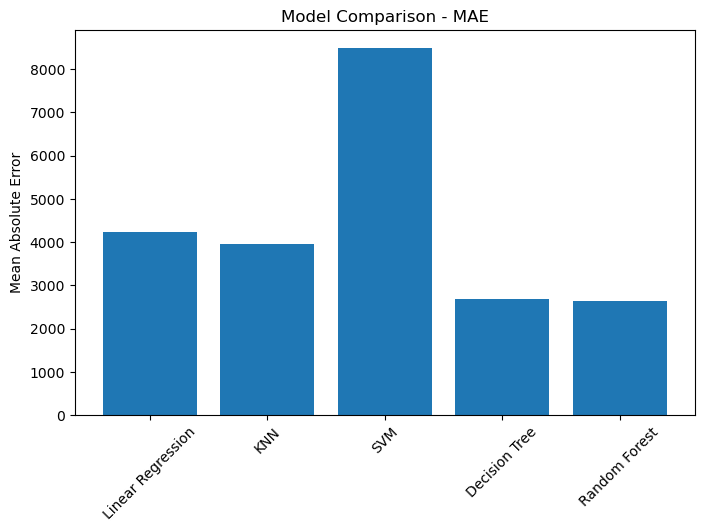

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["MAE"])
plt.xticks(rotation=45)
plt.title("Model Comparison - MAE")
plt.ylabel("Mean Absolute Error")
plt.show()

# Final Model Selection

- ### After comparing all regression models using Mean Absolute Error (MAE) and R² Score:

- ### The model with the lowest MAE is selected.

- ### Random Forest achieved the best performance among all models.

- ### Therefore, Random Forest Regressor is selected as the final model for Medical Cost Prediction.

# Save Best Model

In [56]:
import joblib

joblib.dump(rf_pipeline, "best_model.pkl")

['best_model.pkl']